# **Step 1:Network Configuartion**

In [2]:
#Network_Configuration
# ── Nodes  description ───────────────────────────────────
NODES = {
    'N0_Attacker'     : 'Attacker Machine (Entry Point)',
    'N1_WebServer'    : 'Public Web Server',
    'N2_Firewall'     : 'Firewall',
    'N3_DMZ'          : 'DMZ Server',
    'N4_WorkstationA' : 'Internal Workstation A',
    'N5_WorkstationB' : 'Internal Workstation B',
    'N6_MailServer'   : 'Mail Server',
    'N7_Database'     : 'Database Server',
    'N8_AdminServer'  : 'Admin Server',
    'N9_CriticalAsset': 'Critical Asset HQ (Target)'
}

# ── Edges — (from, to, cost) ───────────────────────────────
# Cost = vulnerability level
EDGES = [
    ('N0_Attacker',     'N1_WebServer',     2),
    ('N0_Attacker',     'N3_DMZ',           4),
    ('N1_WebServer',    'N2_Firewall',       5),
    ('N1_WebServer',    'N3_DMZ',           3),
    ('N2_Firewall',     'N4_WorkstationA',  4),
    ('N3_DMZ',          'N5_WorkstationB',  2),
    ('N3_DMZ',          'N6_MailServer',    6),
    ('N4_WorkstationA', 'N7_Database',      6),
    ('N5_WorkstationB', 'N6_MailServer',    3),
    ('N6_MailServer',   'N8_AdminServer',   4),
    ('N7_Database',     'N9_CriticalAsset', 5),
    ('N8_AdminServer',  'N9_CriticalAsset', 2),
]

# ── Start and Goal ─────────────────────────────────────────
START = 'N0_Attacker'
GOAL  = 'N9_CriticalAsset'

# ── Heuristic — Goal  estimated distance ───────────────

HEURISTIC = {
    'N0_Attacker'     : 9,
    'N1_WebServer'    : 7,
    'N2_Firewall'     : 6,
    'N3_DMZ'          : 6,
    'N4_WorkstationA' : 4,
    'N5_WorkstationB' : 5,
    'N6_MailServer'   : 3,
    'N7_Database'     : 2,
    'N8_AdminServer'  : 2,
    'N9_CriticalAsset': 0
}

# ── Network adjacency list  ─────────────
network = {node: [] for node in NODES}
for frm, to, cost in EDGES:
    network[frm].append((to, cost))

# Imports+Helper functions

In [3]:
# ── Imports ────────────────────────────────────────────────
import time
import heapq
from collections import deque
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def path_cost(path):
    total = 0
    for i in range(len(path) - 1):
        for neighbor, weight in network[path[i]]:
            if neighbor == path[i+1]:
                total += weight
                break
    return total

print("Imports and Helper function ready!")

Imports and Helper function ready!


# Step 3:BFS

In [4]:
# BFS Uninformed Search
def bfs(start, goal):
    start_time     = time.time()
    queue          = deque([[start]])
    visited        = set([start])
    nodes_expanded = 0

    while queue:
        path           = queue.popleft()
        node           = path[-1]
        nodes_expanded += 1

        if node == goal:
            cost    = path_cost(path)
            elapsed = round((time.time() - start_time) * 1000, 4)
            return path, cost, nodes_expanded, elapsed

        for neighbor, _ in network.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None, float('inf'), nodes_expanded, 0

# ── Run ────────────────────────────────
path, cost, expanded, t = bfs(START, GOAL)
print(f"Path           : {' → '.join(path)}")
print(f"Total Cost     : {cost}")
print(f"Nodes Expanded : {expanded}")
print(f"Time (ms)      : {t}")


Path           : N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset
Total Cost     : 16
Nodes Expanded : 10
Time (ms)      : 0.0277


# Step 4:**DFS**

In [5]:

#   DFS — Depth First Search   Uninformed Search

def dfs(start, goal):
    start_time     = time.time()
    stack          = [[start]]
    visited        = set()
    nodes_expanded = 0

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1

        if node == goal:
            cost    = path_cost(path)
            elapsed = round((time.time() - start_time) * 1000, 4)
            return path, cost, nodes_expanded, elapsed

        for neighbor, _ in network.get(node, []):
            if neighbor not in visited:
                stack.append(path + [neighbor])

    return None, float('inf'), nodes_expanded, 0

# ── Run ────────────────────────────────
path, cost, expanded, t = dfs(START, GOAL)
print("=" * 55)
print(" DFS Result")
print("=" * 55)
print(f"   Path           : {' → '.join(path)}")
print(f"   Total Cost     : {cost}")
print(f"   Nodes Expanded : {expanded}")
print(f"   Time (ms)      : {t}")

 DFS Result
   Path           : N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset
   Total Cost     : 16
   Nodes Expanded : 5
   Time (ms)      : 0.0224


# **Step 5:UCS**

In [6]:

#    UCS — Uniform Cost Search
#   Informed Search

def ucs(start, goal):
    start_time     = time.time()
    heap           = [(0, [start])]
    visited        = set()
    nodes_expanded = 0

    while heap:
        cost, path = heapq.heappop(heap)
        node       = path[-1]

        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1

        if node == goal:
            elapsed = round((time.time() - start_time) * 1000, 4)
            return path, cost, nodes_expanded, elapsed

        for neighbor, weight in network.get(node, []):
            if neighbor not in visited:
                heapq.heappush(heap, (cost + weight, path + [neighbor]))

    return None, float('inf'), nodes_expanded, 0

# ── Run ────────────────────────────────
path, cost, expanded, t = ucs(START, GOAL)
print("=" * 55)
print("UCS Result")
print("=" * 55)
print(f"   Path           : {' → '.join(path)}")
print(f"   Total Cost     : {cost}")
print(f"   Nodes Expanded : {expanded}")
print(f"   Time (ms)      : {t}")

UCS Result
   Path           : N0_Attacker → N3_DMZ → N5_WorkstationB → N6_MailServer → N8_AdminServer → N9_CriticalAsset
   Total Cost     : 15
   Nodes Expanded : 9
   Time (ms)      : 0.0281


## Step 6:A*

In [7]:

#    A* Search Algorithm
#    Informed Search
def astar(start, goal):
    start_time     = time.time()
    heap           = [(HEURISTIC[start], 0, [start])]
    visited        = set()
    nodes_expanded = 0

    while heap:
        f, g, path = heapq.heappop(heap)
        node       = path[-1]

        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1

        if node == goal:
            elapsed = round((time.time() - start_time) * 1000, 4)
            return path, g, nodes_expanded, elapsed

        for neighbor, weight in network.get(node, []):
            if neighbor not in visited:
                new_g = g + weight
                new_f = new_g + HEURISTIC.get(neighbor, 0)
                heapq.heappush(heap, (new_f, new_g, path + [neighbor]))

    return None, float('inf'), nodes_expanded, 0

# ── Run ────────────────────────────────
path, cost, expanded, t = astar(START, GOAL)
print("=" * 55)
print(" A* Result")
print("=" * 55)
print(f"   Path           : {' → '.join(path)}")
print(f"   Total Cost     : {cost}")
print(f"   Nodes Expanded : {expanded}")
print(f"   Time (ms)      : {t}")

 A* Result
   Path           : N0_Attacker → N3_DMZ → N5_WorkstationB → N6_MailServer → N8_AdminServer → N9_CriticalAsset
   Total Cost     : 15
   Nodes Expanded : 9
   Time (ms)      : 0.0265


# Step 7:Hill **Climbing**

In [8]:

#    Hill Climbing — Local Search

def hill_climbing(start, goal):
    start_time     = time.time()
    current        = start
    path           = [current]
    visited        = set([current])
    nodes_expanded = 0
    stuck          = False

    while current != goal:
        neighbors = network.get(current, [])
        unvisited = [(n, w) for n, w in neighbors if n not in visited]

        if not unvisited:
            print(f"  LOCAL MAXIMUM! Stuck at: {current}")
            stuck = True
            break

        # Sirf best local neighbor — greedy choice
        next_node, _ = min(unvisited,
                           key=lambda x: HEURISTIC.get(x[0], float('inf')))
        nodes_expanded += 1
        current = next_node
        visited.add(current)
        path.append(current)

    cost    = path_cost(path)
    elapsed = round((time.time() - start_time) * 1000, 4)
    return path, cost, nodes_expanded, elapsed, stuck

# ── Run ────────────────────────────────
path, cost, expanded, t, stuck = hill_climbing(START, GOAL)
print("=" * 55)
print(" Hill Climbing Result")
print("=" * 55)
print(f"   Path           : {' → '.join(path)}")
print(f"   Reached Goal   : {path[-1] == GOAL}")
print(f"   Got Stuck      : {stuck}")
print(f"   Total Cost     : {cost}")
print(f"   Nodes Expanded : {expanded}")
print(f"   Time (ms)      : {t}")

 Hill Climbing Result
   Path           : N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset
   Reached Goal   : True
   Got Stuck      : False
   Total Cost     : 16
   Nodes Expanded : 4
   Time (ms)      : 0.0408


# **Step 8:Minimax + Alpha-Beta**

In [9]:

#   Minimax + Alpha-Beta Pruning
#    Adversarial Search
minimax_calls   = 0
alphabeta_calls = 0

# ── Minimax ────────────────────────────
def minimax(node, depth, is_maximizing, visited=None):
    global minimax_calls
    minimax_calls += 1
    if visited is None:
        visited = set()
    if node == GOAL:
        return 100
    if depth == 0:
        return HEURISTIC.get(node, 0)

    visited   = visited | {node}
    neighbors = [n for n, _ in network.get(node, []) if n not in visited]
    if not neighbors:
        return HEURISTIC.get(node, 0)

    if is_maximizing:
        best = float('-inf')
        for nb in neighbors:
            best = max(best, minimax(nb, depth-1, False, visited))
        return best
    else:
        best = float('inf')
        for nb in neighbors:
            best = min(best, minimax(nb, depth-1, True, visited))
        return best

# ── Alpha-Beta ─────────────────────────
def alpha_beta(node, depth, alpha, beta, is_maximizing, visited=None):
    global alphabeta_calls
    alphabeta_calls += 1
    if visited is None:
        visited = set()
    if node == GOAL:
        return 100
    if depth == 0:
        return HEURISTIC.get(node, 0)

    visited   = visited | {node}
    neighbors = [n for n, _ in network.get(node, []) if n not in visited]
    if not neighbors:
        return HEURISTIC.get(node, 0)

    if is_maximizing:
        best = float('-inf')
        for nb in neighbors:
            best  = max(best, alpha_beta(nb, depth-1, alpha, beta, False, visited))
            alpha = max(alpha, best)
            if beta <= alpha:
                break  #  Pruning
        return best
    else:
        best = float('inf')
        for nb in neighbors:
            best = min(best, alpha_beta(nb, depth-1, alpha, beta, True, visited))
            beta = min(beta, best)
            if beta <= alpha:
                break  #  Pruning
        return best

# ── Run ────────────────────────────────
minimax_calls = alphabeta_calls = 0

t1       = time.time()
mm_score = minimax(START, 4, True)
mm_time  = round((time.time() - t1) * 1000, 4)
mm_calls = minimax_calls

t2       = time.time()
ab_score = alpha_beta(START, 4, float('-inf'), float('inf'), True)
ab_time  = round((time.time() - t2) * 1000, 4)
ab_calls = alphabeta_calls

print("=" * 55)
print(" Minimax vs Alpha-Beta")
print("=" * 55)
print(f"   Minimax    — Score: {mm_score} | Calls: {mm_calls} | Time: {mm_time} ms")
print(f"   Alpha-Beta — Score: {ab_score} | Calls: {ab_calls} | Time: {ab_time} ms")
print(f"    Pruning ne {mm_calls - ab_calls} calls bachaye!")

 Minimax vs Alpha-Beta
   Minimax    — Score: 2 | Calls: 17 | Time: 0.1915 ms
   Alpha-Beta — Score: 2 | Calls: 12 | Time: 0.159 ms
    Pruning ne 5 calls bachaye!


# Step 9:Final Comparison Table + Graph


📊  ALGORITHM COMPARISON TABLE
    Algorithm                                                                                       Path  Total Cost  Nodes Expanded  Time (ms)
          BFS                   N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset          16              10     0.0229
          DFS                   N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset          16               5     0.0081
          UCS N0_Attacker → N3_DMZ → N5_WorkstationB → N6_MailServer → N8_AdminServer → N9_CriticalAsset          15               9     0.0134
           A* N0_Attacker → N3_DMZ → N5_WorkstationB → N6_MailServer → N8_AdminServer → N9_CriticalAsset          15               9     0.0122
Hill Climbing                   N0_Attacker → N3_DMZ → N6_MailServer → N8_AdminServer → N9_CriticalAsset          16               4     0.0207


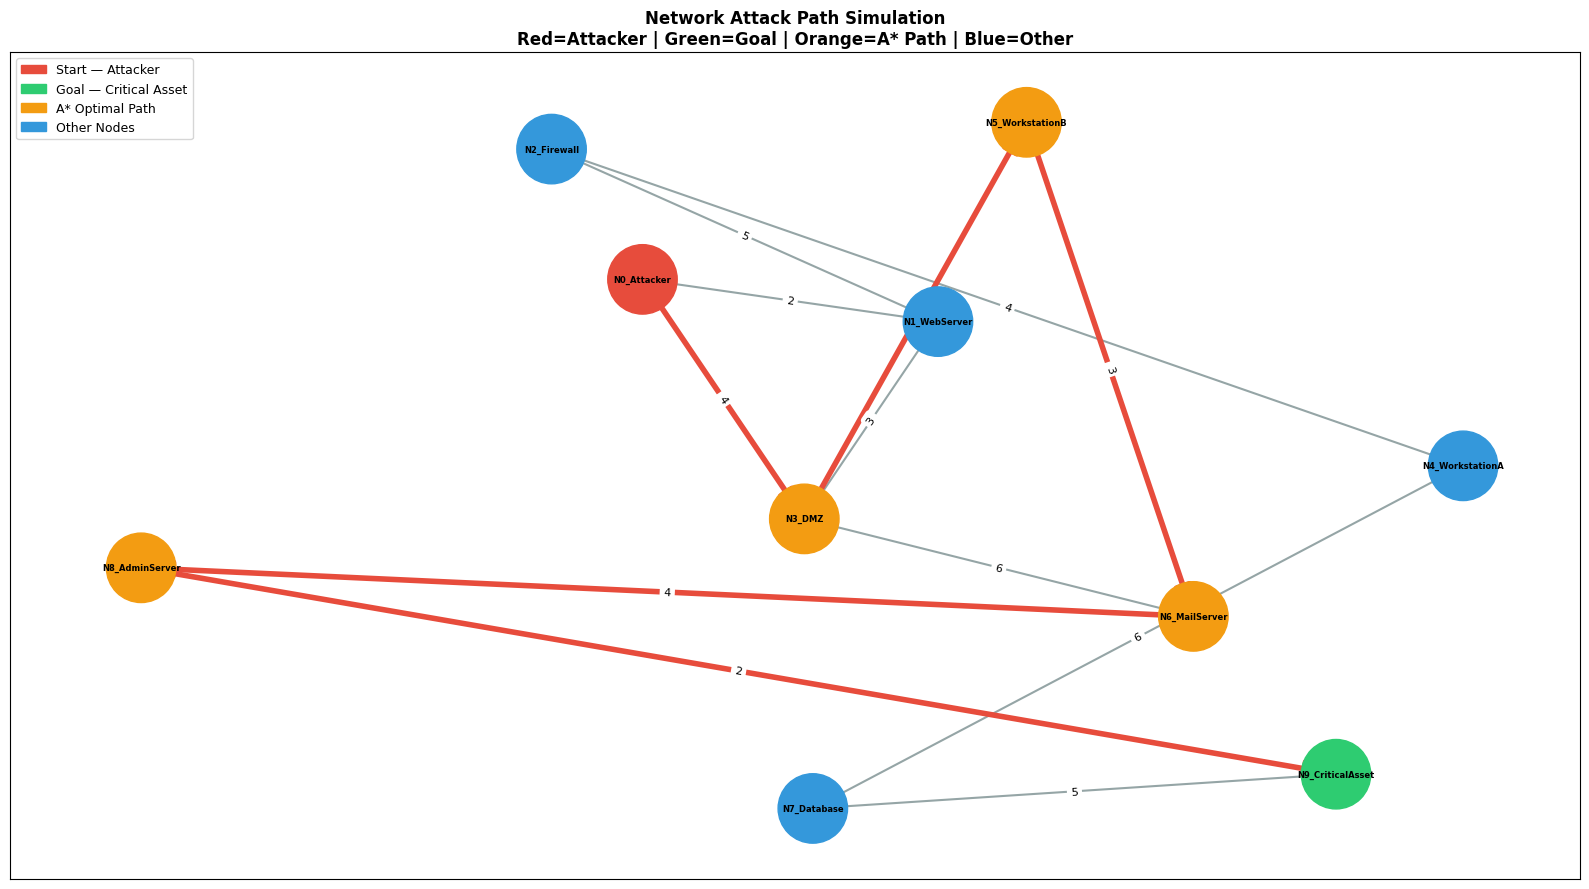

✅ Graph saved!


In [10]:

#   Comparison Table + Visualization


# ── Run all algorithms ──
r_bfs              = bfs(START, GOAL)
r_dfs              = dfs(START, GOAL)
r_ucs              = ucs(START, GOAL)
r_astar            = astar(START, GOAL)
r_hc_p, r_hc_c, r_hc_e, r_hc_t, _ = hill_climbing(START, GOAL)

# ── Table ──────────────────────────────
rows = [
    {"Algorithm": "BFS",
     "Path": " → ".join(r_bfs[0]),
     "Total Cost": r_bfs[1],
     "Nodes Expanded": r_bfs[2],
     "Time (ms)": r_bfs[3]},

    {"Algorithm": "DFS",
     "Path": " → ".join(r_dfs[0]),
     "Total Cost": r_dfs[1],
     "Nodes Expanded": r_dfs[2],
     "Time (ms)": r_dfs[3]},

    {"Algorithm": "UCS",
     "Path": " → ".join(r_ucs[0]),
     "Total Cost": r_ucs[1],
     "Nodes Expanded": r_ucs[2],
     "Time (ms)": r_ucs[3]},

    {"Algorithm": "A*",
     "Path": " → ".join(r_astar[0]),
     "Total Cost": r_astar[1],
     "Nodes Expanded": r_astar[2],
     "Time (ms)": r_astar[3]},

    {"Algorithm": "Hill Climbing",
     "Path": " → ".join(r_hc_p),
     "Total Cost": r_hc_c,
     "Nodes Expanded": r_hc_e,
     "Time (ms)": r_hc_t},
]

df = pd.DataFrame(rows)
print("\n" + "=" * 95)
print("📊  ALGORITHM COMPARISON TABLE")
print("=" * 95)
print(df.to_string(index=False))
print("=" * 95)

# ── Network Graph ──────────────────────
G = nx.DiGraph()
for frm, to, cost in EDGES:
    G.add_edge(frm, to, weight=cost)

pos         = nx.spring_layout(G, seed=42, k=2)
edge_labels = nx.get_edge_attributes(G, 'weight')

astar_path  = r_astar[0]
path_edges  = [(astar_path[i], astar_path[i+1])
               for i in range(len(astar_path)-1)]
other_edges = [e for e in G.edges() if e not in path_edges]

node_colors = []
for node in G.nodes():
    if node == START:
        node_colors.append('#e74c3c')
    elif node == GOAL:
        node_colors.append('#2ecc71')
    elif node in astar_path:
        node_colors.append('#f39c12')
    else:
        node_colors.append('#3498db')

plt.figure(figsize=(16, 9))
plt.title("Network Attack Path Simulation\n"
          "Red=Attacker | Green=Goal | Orange=A* Path | Blue=Other",
          fontsize=12, fontweight='bold')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500)
nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=other_edges,
                       edge_color='#95a5a6', arrows=True,
                       arrowsize=20, width=1.5)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='#e74c3c', arrows=True,
                       arrowsize=25, width=4)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

legend = [
    mpatches.Patch(color='#e74c3c', label='Start — Attacker'),
    mpatches.Patch(color='#2ecc71', label='Goal — Critical Asset'),
    mpatches.Patch(color='#f39c12', label='A* Optimal Path'),
    mpatches.Patch(color='#3498db', label='Other Nodes'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph saved!")

# UI DESIGN

In [ ]:
# ================================
# UI — Simple 4 Screens
# Colab ki last cell mein paste karo
# ================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ============================================================
# INTERACTIVE UI — Click karo, output dekho!
# Colab ki last cell mein paste karo
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ── Network Graph Setup ──────────────────────────────────
G = nx.DiGraph()
for frm, to, cost in EDGES:
    G.add_edge(frm, to, weight=cost)
pos = nx.spring_layout(G, seed=42, k=2)

short = {n: n.split('_',1)[1] if '_' in n else n for n in G.nodes()}

# ── Graph Drawing Function ───────────────────────────────
def draw_graph(highlight_path=None):
    path_edges = []
    if highlight_path:
        path_edges = [(highlight_path[i], highlight_path[i+1])
                      for i in range(len(highlight_path)-1)]
    other_edges = [e for e in G.edges() if e not in path_edges]

    node_colors = []
    for node in G.nodes():
        if node == START:                    node_colors.append('#e74c3c')
        elif node == GOAL:                   node_colors.append('#2ecc71')
        elif highlight_path and node in highlight_path: node_colors.append('#f39c12')
        else:                                node_colors.append('#3498db')

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor('#0a0a2e')
    ax.set_facecolor('#0a0a2e')
    ax.axis('off')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=short, font_size=8,
                            font_color='white', font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=other_edges,
                           edge_color='gray', arrows=True, arrowsize=15, width=1.5, ax=ax)
    if path_edges:
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='#e74c3c', arrows=True, arrowsize=22, width=4, ax=ax)
    nx.draw_networkx_edge_labels(G, pos,
                                  edge_labels=nx.get_edge_attributes(G,'weight'),
                                  font_size=8, font_color='yellow', ax=ax)

    legend = [mpatches.Patch(color='#e74c3c', label='Attacker (Start)'),
              mpatches.Patch(color='#2ecc71', label='Goal'),
              mpatches.Patch(color='#f39c12', label='Found Path'),
              mpatches.Patch(color='#3498db', label='Other Nodes')]
    ax.legend(handles=legend, loc='upper left', fontsize=9,
              facecolor='#1a1a3e', labelcolor='white')
    plt.tight_layout()
    plt.show()

# ── Run Algorithm Function ───────────────────────────────
def run_algorithm(algo_name):
    if algo_name == 'BFS':
        path, cost, nodes, t = bfs(START, GOAL)
    elif algo_name == 'DFS':
        path, cost, nodes, t = dfs(START, GOAL)
    elif algo_name == 'UCS':
        path, cost, nodes, t = ucs(START, GOAL)
    elif algo_name == 'A*':
        path, cost, nodes, t = astar(START, GOAL)
    elif algo_name == 'Hill Climbing':
        path, cost, nodes, t, _ = hill_climbing(START, GOAL)
    elif algo_name == 'Minimax':
        import time
        global minimax_calls
        minimax_calls = 0
        t1 = time.time()
        score = minimax(START, 4, True)
        t = round((time.time()-t1)*1000, 4)
        path, cost, nodes = None, score, minimax_calls
    elif algo_name == 'Alpha-Beta':
        import time
        global alphabeta_calls
        alphabeta_calls = 0
        t1 = time.time()
        score = alpha_beta(START, 4, float('-inf'), float('inf'), True)
        t = round((time.time()-t1)*1000, 4)
        path, cost, nodes = None, score, alphabeta_calls
    return path, cost, nodes, t

# ── Output Area ──────────────────────────────────────────
out = widgets.Output()

# ── Button Click Handler ─────────────────────────────────
def on_click(algo_name):
    with out:
        clear_output(wait=True)

        # Header
        print(f"\n{'='*55}")
        print(f"  🤖  Algorithm: {algo_name}")
        print(f"{'='*55}")

        path, cost, nodes, t = run_algorithm(algo_name)

        if path:
            print(f"  📍 Path    : {' → '.join([s.split('_',1)[1] if '_' in s else s for s in path])}")
            print(f"  💰 Cost    : {cost}")
            print(f"  🔍 Nodes   : {nodes}")
            print(f"  ⏱️  Time    : {t} ms")
            print(f"{'='*55}\n")
            draw_graph(highlight_path=path)
        else:
            print(f"  📊 Score   : {cost}")
            print(f"  🔍 Calls   : {nodes}")
            print(f"  ⏱️  Time    : {t} ms")
            print(f"{'='*55}\n")
            draw_graph()

# ── Compare All Button ───────────────────────────────────
def on_compare(b):
    with out:
        clear_output(wait=True)
        print("\n📊 ALGORITHM COMPARISON TABLE")
        print("="*75)
        print(f"{'Algorithm':<15} {'Cost':<8} {'Nodes':<10} {'Time(ms)':<12} {'Path'}")
        print("-"*75)

        algos = ['BFS','DFS','UCS','A*','Hill Climbing']
        for a in algos:
            path, cost, nodes, t = run_algorithm(a)
            short_path = '→'.join([s.split('_',1)[1] if '_' in s else s for s in path])
            print(f"{a:<15} {cost:<8} {nodes:<10} {t:<12} {short_path}")

        print("="*75)

        # Bar chart
        costs = []
        node_counts = []
        for a in algos:
            p, c, n, t = run_algorithm(a)
            costs.append(c)
            node_counts.append(n)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor('#0a0a2e')
        colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c']

        for ax, data, title, ylabel in [
            (axes[0], costs,       'Total Path Cost',  'Cost'),
            (axes[1], node_counts, 'Nodes Expanded',   'Nodes')
        ]:
            ax.set_facecolor('#0d0d3e')
            bars = ax.bar(algos, data, color=colors, edgecolor='white')
            for bar, val in zip(bars, data):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.1, str(val),
                        ha='center', color='white', fontweight='bold')
            ax.set_title(title, color='white', fontweight='bold')
            ax.tick_params(colors='white')
            ax.spines[:].set_color('#3498db')
            ax.set_ylabel(ylabel, color='white')

        plt.suptitle('Algorithm Comparison', color='white',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

# ── Build UI Layout ──────────────────────────────────────

# Title
title = widgets.HTML(
    value="<div style='background:#0a0a2e; color:#e74c3c; "
          "font-size:22px; font-weight:bold; text-align:center; "
          "padding:15px; border-radius:10px; border:2px solid #e74c3c;'>"
          "🛡️ Network Attack Simulator</div>"
)

subtitle = widgets.HTML(
    value="<div style='background:#0a0a2e; color:white; "
          "font-size:13px; text-align:center; padding:8px;'>"
          "Haseeba Ajmeer | Iman Nasir | CSC 262</div>"
)

# Algorithm Buttons
btn_style = {'button_color': '', 'font_weight': 'bold'}

btn_bfs   = widgets.Button(description='BFS',           style={'button_color':'#e74c3c'}, layout=widgets.Layout(width='130px', height='45px'))
btn_dfs   = widgets.Button(description='DFS',           style={'button_color':'#e67e22'}, layout=widgets.Layout(width='130px', height='45px'))
btn_ucs   = widgets.Button(description='UCS',           style={'button_color':'#d4ac0d'}, layout=widgets.Layout(width='130px', height='45px'))
btn_astar = widgets.Button(description='A*',            style={'button_color':'#27ae60'}, layout=widgets.Layout(width='130px', height='45px'))
btn_hc    = widgets.Button(description='Hill Climbing', style={'button_color':'#1abc9c'}, layout=widgets.Layout(width='150px', height='45px'))
btn_mm    = widgets.Button(description='Minimax',       style={'button_color':'#2980b9'}, layout=widgets.Layout(width='130px', height='45px'))
btn_ab    = widgets.Button(description='Alpha-Beta',    style={'button_color':'#8e44ad'}, layout=widgets.Layout(width='130px', height='45px'))
btn_cmp   = widgets.Button(description='📊 Compare All',style={'button_color':'#c0392b'}, layout=widgets.Layout(width='200px', height='50px'))

# Click events
btn_bfs.on_click(lambda b: on_click('BFS'))
btn_dfs.on_click(lambda b: on_click('DFS'))
btn_ucs.on_click(lambda b: on_click('UCS'))
btn_astar.on_click(lambda b: on_click('A*'))
btn_hc.on_click(lambda b: on_click('Hill Climbing'))
btn_mm.on_click(lambda b: on_click('Minimax'))
btn_ab.on_click(lambda b: on_click('Alpha-Beta'))
btn_cmp.on_click(on_compare)

# Layout
label = widgets.HTML("<div style='color:#f39c12; font-weight:bold; font-size:14px; padding:8px;'>Select Algorithm:</div>")
row1  = widgets.HBox([btn_bfs, btn_dfs, btn_ucs, btn_astar])
row2  = widgets.HBox([btn_hc, btn_mm, btn_ab])
row3  = widgets.HBox([btn_cmp])

ui = widgets.VBox([title, subtitle, label, row1, row2, row3, out])
display(ui)